# 图像处理基础练习（第一阶段 · 基础图像处理）

对应文档第一阶段"编程能力强化 → 基础图像处理"：掌握 OpenCV / skimage 的医学图像常用操作（灰度转换、直方图均衡、形态学操作、坐标变换、图像 IO）。

**练习素材**：全部用 skimage 自带的示例图像（腹部 MRI、眼底彩照、荧光显微细胞），不需要下载数据集，任何人拿到这个 notebook 都能原样跑通。

**主线**：图像 IO → 灰度转换 → 坐标变换（缩放 / 旋转 / 翻转）→ 直方图与直方图均衡 → 形态学操作。

**配套脚本**：`preprocess.py` 把上面这些操作串成一条可复用的预处理流水线，支持命令行调用。

**环境**：conda 环境 `pytorch`，scikit-image 0.26.0、OpenCV 5.0.0、matplotlib 3.11.1。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from skimage import data, io, color, transform, exposure, filters, util
from skimage.morphology import disk, opening, closing
import cv2
from torchvision import datasets

# print(np.__version__, cv2.__version__)

## 一、图像在计算机里是什么

### 说明

图像在计算机里就是一个**数字矩阵**：每个元素是一个像素的亮度值。建立这个认识之后，后面所有操作（缩放、均衡、形态学）都能理解成"对这个矩阵做数学运算"，而不是黑箱。

### 三个必须先看的属性

| 属性 | 含义 | 例子 |
| --- | --- | --- |
| `shape` | 形状：几行几列（几层） | `(28, 28)` 表示高 28、宽 28 |
| `dtype` | 数据类型：每个像素用什么数字存 | `uint8` 表示 0~255 的整数 |
| 通道 | 彩色图 3 层（RGB），灰度图 1 层 | `(512, 512, 3)` 对比 `(512, 512)` |

### 为什么先做这一步

拿到任何一张陌生图像，先打印这三个值，这是排查问题的第一习惯。下一节马上就会看到：不看这三个值，图像显示出来是一片白，而且完全不知道为什么。

### 我观察到

MNIST 的图是 `(28, 28)` 的 uint8，取值 0~255。28×28 足够小，可以直接把整块像素打印出来看——图像真的就是一堆数字。

In [2]:
mnist = datasets.MNIST(root='../data', train=False, download=False)
image, label = mnist[0]
arr = np.array(image)
print('shape:', arr.shape, 'dtype:', arr.dtype, 'min:', arr.min(), 'max:', arr.max())

shape: (28, 28) dtype: uint8 min: 0 max: 255


## 二、真实医学图像：先看 shape / dtype / min / max

### 说明

`data.kidney()` 是 skimage 自带的腹部 MRI 数据。这一节刻意**没有**直接显示图像，而是先打印四个值。

### 为什么

因为这一步的结果直接决定图能不能正常显示。实测发现：

- shape 是 `(16, 512, 512, 3)`——它根本不是一个二维切片，而是 **16 层**的体数据（医学里叫断层序列，一次扫描会有几十上百层）
- 最大值 `4095 = 2¹² - 1`，说明这是 **12 位**数据，不是常见的 8 位（0~255）
- 最后一维是 3，说明每个切片是三通道

### 结论

医学图像和网上的普通照片有三个根本区别：**层数（3D 体数据）、位深（常见 12/16 位）、通道的物理含义**。所以"拿到数据先看四个值"不是形式主义，而是必需的。这个显示问题是怎么回事，见文末「附一」。

### 我观察到

最小值是 10 而不是 0，最大值 4095 也不是 65535。说明这是设备直接输出的原始数据，没有被归一化过——这一点在处理真实医学数据时很关键，因为**不同设备的数值刻度不一样**。


C:\Users\35314\miniconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [64..4095].


shape: (16, 512, 512, 3) dtype: uint16 min: 10 max: 4095


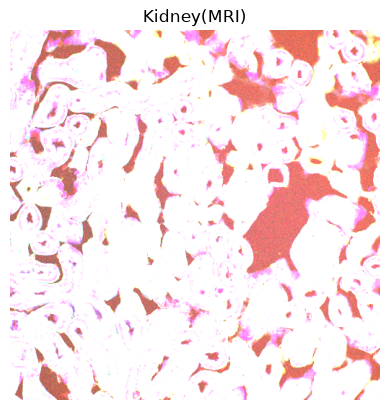

In [3]:
mri = data.kidney()
print('shape:', mri.shape, 'dtype:', mri.dtype, 'min:', mri.min(), 'max:', mri.max())
slice_2d = mri[8]

# --- 显示前先看四个值：shape / dtype / min / max ---
# 这里的结果是 (16, 512, 512, 3) uint16，min=10，max=4095，含义有三层：
#   1) 最后一维是 3 -> 每个切片是三通道(RGB)，matplotlib 按彩色图处理，cmap='gray' 会被忽略；
#   2) 4095 = 2**12 - 1 -> 这是 12 位数据，不是常见的 8 位(0~255)；
#   3) 三通道数据 matplotlib 不做自动缩放，只认 0~1(float) 或 0~255(整数)，超出的会被截断成 255。
# 所以下面这张图大部分像素被压成纯白，看着像'什么都没有'。完整原理见本文件末尾的 markdown 说明。
plt.imshow(slice_2d, cmap='gray')
plt.title("Kidney(MRI)")
plt.axis("off")
plt.show()

In [4]:
print([n for n in dir(data) if not n.startswith("_")])

['astronaut', 'binary_blobs', 'brain', 'brick', 'camera', 'cat', 'cell', 'cells3d', 'checkerboard', 'chelsea', 'clock', 'coffee', 'coins', 'colorwheel', 'data_dir', 'download_all', 'eagle', 'file_hash', 'grass', 'gravel', 'horse', 'hubble_deep_field', 'human_mitosis', 'immunohistochemistry', 'kidney', 'lbp_frontal_face_cascade_filename', 'lfw_subset', 'lily', 'logo', 'microaneurysms', 'moon', 'nickel_solidification', 'page', 'palisades_of_vogt', 'protein_transport', 'retina', 'rocket', 'shepp_logan_phantom', 'skin', 'stereo_motorcycle', 'text', 'vortex']


## 三、图像 IO：读进来、存出去

### 说明

- `io.imread(路径)`：把磁盘上的图像文件读成 numpy 数组
- `io.imsave(路径, 数组)`：把数组写回成图像文件

### 为什么

任何图像分析的第一步都是"把文件变成数组"，最后一步是"把结果变回文件"。这一步还顺带回答一个重要问题：**存一次再读一次，数据会不会变？**

### 关键理解：两种"换算"不是一回事

| 做法 | 换算规则 | 结果 |
| --- | --- | --- |
| `(x / x.max() * 255)` | 按**这张图自己的**最大最小值线性拉伸 | 把 10~4095 铺满到 0~255 |
| `util.img_as_ubyte(x)` | 按**数据类型的满量程**换算 | 4095（满量程 65535）→ 15，图像几乎全黑 |

前者是"为了让图看得清楚"，后者是"忠实换算"。医学图像预处理里两者都会用到，但**混用会造成灾难性结果**。

### 我观察到

把切片存成 PNG 再读回来，`np.array_equal` 是 True——PNG 是无损压缩。把扩展名换成 jpg 就不相等了，因为 jpg 是有损压缩。

**这就是医学图像普遍用 PNG / TIFF / DICOM 而不用 JPG 的原因**：诊断信息不能被压缩算法丢掉。

(512, 512, 3) uint8
和原图一样吗？ True


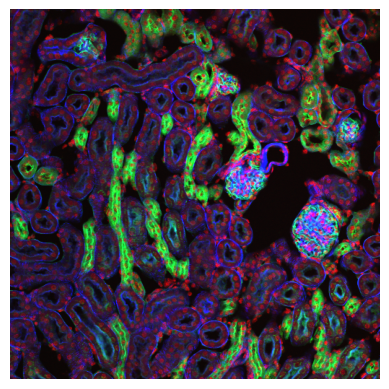

In [5]:
# 把数值换算到 matplotlib 认的刻度：先除以本切片最大值(变成 0~1)，再乘 255(变成 0~255)。
# 注意：这只是线性拉伸(min-max 归一化)，像素之间的相对亮暗关系没变，变的只是显示的刻度。
# 别和 util.img_as_ubyte 搞混：它按 dtype 的满量程(uint16 对 65535)换算，4095 会变成 15，图会几乎全黑。
slice_u8 = (slice_2d / slice_2d.max() * 255).astype(np.uint8)
io.imsave("outputs/kidney.png", slice_u8)
back = io.imread("outputs/kidney.png")
plt.imshow(back, cmap='gray')
plt.axis("off")
print(back.shape, back.dtype)
print("和原图一样吗？", np.array_equal(slice_u8, back))

## 四、灰度转换

### 说明

把 3 通道的彩色图合成 1 通道的灰度图。`rgb2gray` 按人眼对红绿蓝的敏感程度**加权**计算，不是简单取平均。

### 医学里用在哪

CT、MRI、超声本身测的是组织对 X 光或磁场的响应强度，**不是颜色**，所以原始数据本来就是灰度。彩色只出现在眼底照、病理染色这类特定模态里。另外模型的输入通道数必须固定，所以预处理时通常要先统一成单通道。

### 我观察到

`rgb2gray` 返回的是 **0~1 的 float**，而原图是 **0~255 的 uint8**，需要用 `img_as_ubyte` 转回去才能正常显示和保存。这引出一条铁律：

> **动手处理图像之前，先看 dtype。** 0~1 的 float 和 0~255 的 uint8 混用，会得到全黑、全白或者完全错误的结果。

shape: (1411, 1411, 3) dtype: uint8 min: 0 max: 255
shape: (1411, 1411) dtype: float64 min: 0.0 max: 0.9229600000000001
shape: (1411, 1411) dtype: uint8 min: 0 max: 235


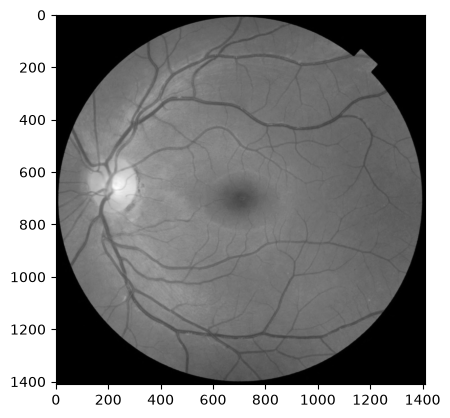

In [6]:
# 转换为灰度图
retina = data.retina()
print('shape:', retina.shape, 'dtype:', retina.dtype, 'min:', retina.min(), 'max:', retina.max())
gray_float = color.rgb2gray(retina)
gray_byte = util.img_as_ubyte(gray_float)
print('shape:', gray_float.shape, 'dtype:', gray_float.dtype, 'min:', gray_float.min(), 'max:', gray_float.max())
print('shape:', gray_byte.shape, 'dtype:', gray_byte.dtype, 'min:', gray_byte.min(), 'max:', gray_byte.max())
plt.imshow(gray_byte, cmap='gray')

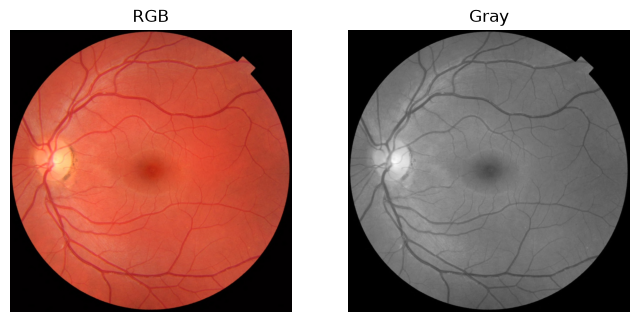

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(retina)
axes[0].set_title("RGB")
axes[1].imshow(gray_byte, cmap="gray")
axes[1].set_title("Gray")
for ax in axes: ax.axis("off")
plt.savefig("outputs/01_gray_compare.png", dpi=120, bbox_inches='tight')
plt.show()

## 五、坐标变换（一）：缩放（重采样）

### 说明

改变图像的尺寸。新图上的每个像素值要靠原图周围的像素算出来，这个过程叫**重采样**，具体算法叫**插值**。

### 两个参数的意义

- `anti_aliasing=True`：缩小图像时开启抗锯齿，避免出现一圈一圈的假纹理（摩尔纹）
- 注意 `transform.resize` 对 uint8 输入默认返回 0~1 的 float，所以后面要 `* 255` 再转回 uint8 才能正常显示

### 医学里用在哪

**这是医学图像预处理里最重要的一步。** 不同医院、不同设备的扫描参数不同，出来的图像尺寸五花八门（512×512、256×256、非方形尺寸都有），而模型只能吃固定尺寸的输入，所以必须先统一——医学上叫"重采样到统一的空间分辨率"。

### 我观察到

512×512 缩到 128×128，面积变成原来的 1/16，每个新像素大约由原来 16 个像素共同决定。（反过来放大时，新像素的值靠插值"猜"出来，所以放大不会增加真实信息。）

原图大小: (512, 512, 3) uint8 缩小后: (128, 128, 3) uint8


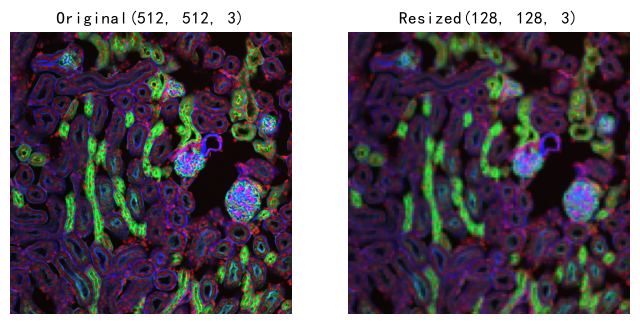

In [17]:
# 缩放
small = transform.resize(slice_u8, (128, 128), anti_aliasing=True)
small = (small * 255).astype(np.uint8)
# small = util.img_as_ubyte(small)
print("原图大小:", slice_u8.shape, slice_u8.dtype, "缩小后:", small.shape, small.dtype)
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(slice_u8, cmap="gray")
axes[0].set_title(f"Original{slice_u8.shape}")
axes[1].imshow(small, cmap="gray")
axes[1].set_title(f"Resized{small.shape}")
for ax in axes: ax.axis("off")
plt.savefig("outputs/02_resize_compare.png", dpi=120, bbox_inches='tight')
plt.show()

## 六、坐标变换（二）：旋转与翻转

### 说明

- `transform.rotate(img, 90)`：旋转（这里转 90 度，是为了让差异一眼可见）
- `np.fliplr(img)`：左右镜像，本质是把矩阵的列顺序倒过来

### 医学里用在哪

主要用于**数据增强**——训练数据不够时，用翻转、旋转、平移人为造出更多样本。你在 Fashion-MNIST 里用过的 `RandomHorizontalFlip` 就是同一个东西。

### 但医学图像有特殊性（重要）

服装左右翻转后还是同一件衣服，所以增强是安全的。**胸片不行**：影像上有左右方位信息，翻转之后"左肺"变成"右肺"，如果标签是按真实病灶位置写的，就把答案改错了。

旋转同样要谨慎：CT / MRI 有明确的解剖方位约定（头脚、左右、腹背），随意旋转在真实科研里需要配合坐标系变换一起做，不是随手转。

> **结论：数据增强策略要服从领域的物理含义，不能照搬自然图像那一套。**

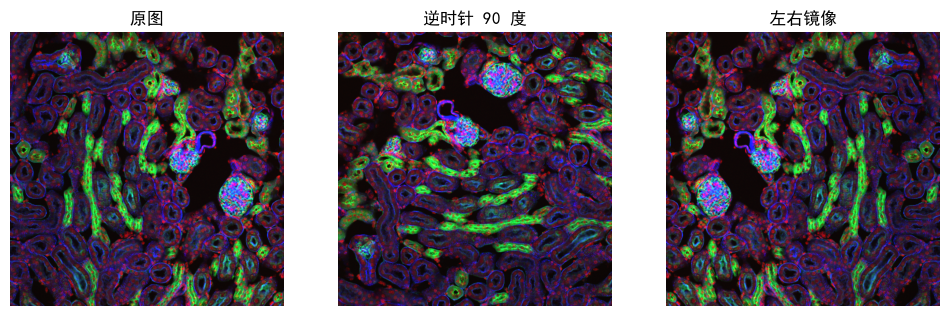

In [9]:
# 旋转与翻转
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows 用黑体
plt.rcParams['axes.unicode_minus'] = False    # 正常显示负号
rot = transform.rotate(slice_u8, 90)
flip = np.fliplr(slice_u8)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(slice_u8, cmap="gray");  axes[0].set_title("原图")
axes[1].imshow(rot, cmap="gray");  axes[1].set_title("逆时针 90 度")
axes[2].imshow(flip, cmap="gray"); axes[2].set_title("左右镜像")
for ax in axes: ax.axis("off")
plt.savefig("outputs/03_geometry.png", dpi=120, bbox_inches="tight")
plt.show()

## 七、直方图

### 说明

直方图统计的是"每个亮度值上各有多少个像素"。`ravel()` 把二维矩阵压成一维长条，因为统计亮度分布不需要知道像素的位置。

### 为什么看它

直方图是判断"图像亮不亮、对比度够不够"最快的工具：

- 像素都挤在一小段范围里 → 图像灰蒙蒙、细节看不清
- 出现两个离得很远的峰 → 通常说明图像里有两大类区域（例如暗背景 + 亮的器官）

### 医学里用在哪

CT 图像中不同组织的 CT 值差异很明确，直方图（以及它的各种变体）常被用来做**组织分割、病灶区域分析**。

### 关键坑

**直方图只能统计单通道图像。** 彩色图直接 `ravel()` 会把三个通道的像素混在一起统计，得到的既不是红通道的分布也不是灰度分布，没有意义。所以做直方图之前必须先转灰度（下一节的代码就是这样处理的）。

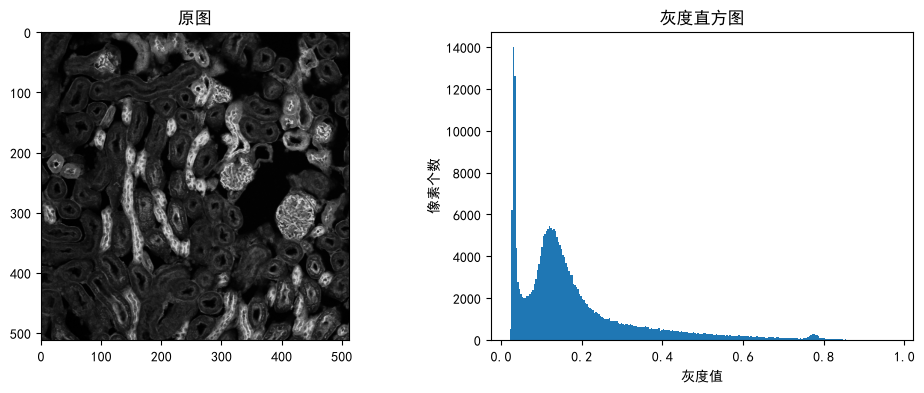

In [10]:
# 直方图
gray_slice = color.rgb2gray(slice_u8)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(gray_slice, cmap="gray"); axes[0].set_title("原图")
axes[1].hist(gray_slice.ravel(), bins=256)
axes[1].set_title("灰度直方图")
axes[1].set_xlabel("灰度值")
axes[1].set_ylabel("像素个数")
plt.savefig("outputs/04_histogram.png", dpi=120, bbox_inches="tight")
plt.show()

## 八、直方图均衡

### 说明

把像素亮度重新分配，让直方图变得平坦，从而把挤在一起的亮暗差距拉开——图像对比度变强。

### 医学里用在哪

这正是 CT **窗宽窗位（window width / window level）**调整要解决的问题：把有用的那一段亮度范围拉开、把没用的压掉。影像科医生每天调的就是这个。

### 我踩到过的坑

**彩色图不能直接做直方图均衡。** `equalize_hist` 对多通道图是**逐通道各自均衡**的，三个通道被拉成不同的曲线，通道之间的颜色关系就被破坏了。第一版我直接对三通道图做，结果图像变成紫一块绿一块，颜色完全失真。

正确做法二选一：

- 先转灰度再均衡（本 notebook 采用）
- 或者转到 HSV 空间，只对 V（亮度）通道做均衡，再转回 RGB

### 均衡不是永远更好

- 它会把噪声一起放大
- 如果病灶和周围组织的对比本来就很微弱，均衡之后可能反而更难分辨
- 所以临床上医生用的是**有选择的**窗宽窗位，而不是无脑均衡

### 我观察到

原图的直方图挤在左侧一小段（0.05~0.2 之间那两个峰），均衡之后铺满整个 0~1 区间；图像上原来暗得看不清的纹理变得清楚了。

均衡后取值范围: 0.00199127197265625 1.0


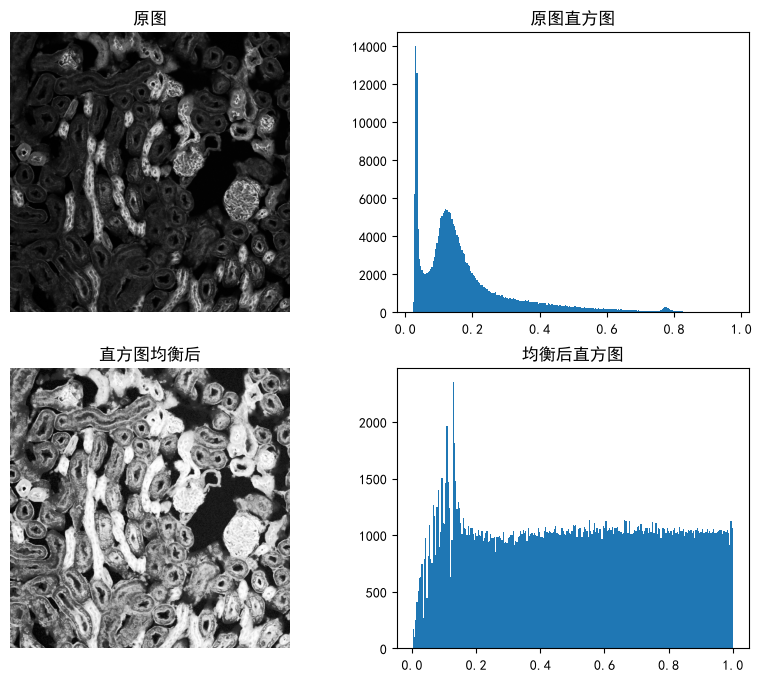

In [11]:
# 直方图均衡
eq = exposure.equalize_hist(gray_slice)
print("均衡后取值范围:", eq.min(), eq.max())
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(gray_slice, cmap="gray"); axes[0, 0].set_title("原图")
axes[0, 1].hist(gray_slice.ravel(), bins=256); axes[0, 1].set_title("原图直方图")
axes[1, 0].imshow(eq, cmap="gray"); axes[1, 0].set_title("直方图均衡后")
axes[1, 1].hist(eq.ravel(), bins=256);axes[1, 1].set_title("均衡后直方图")
for ax in (axes[0, 0], axes[1, 0]): ax.axis("off")
plt.savefig("outputs/05_equalize.png", dpi=120, bbox_inches="tight")
plt.show()


## 九、形态学操作

### 说明

拿一个**很小的形状**（叫结构元 / kernel，比如半径 3 的圆盘 `disk(3)`）在图像上滑动，对覆盖到的区域做"取最大 / 取最小"之类的运算。四个基本操作：

| 操作 | 效果 | 用途 |
| --- | --- | --- |
| 腐蚀 erosion | 亮的区域变小 | 消掉孤立的小亮点 |
| 膨胀 dilation | 亮的区域变大 | 填小洞、把断开的连起来 |
| 开运算 opening | 先腐蚀后膨胀 | 去掉小噪点，整体形状基本不变 |
| 闭运算 closing | 先膨胀后腐蚀 | 填小洞，把缝隙连起来 |

本节的输入是**二值掩膜**：先用 Otsu 法自动找一个阈值，把显微细胞图切成"是细胞 / 不是细胞"两种值。Otsu 会自动挑一个让前景和背景差异最大的阈值，不用手调。

### 医学里用在哪

和第二阶段的分割任务直接相关：模型（U-Net 那类）输出的是掩膜，掩膜上经常有零散的小碎点和小空洞，清理它们全靠形态学。

### 参数敏感度（这节最有价值的发现）

我对比了不同 kernel 大小下，开运算保留的目标像素占比（原掩膜占全图 11.36%）：

| kernel | 剩余目标占比 |
| --- | --- |
| disk(1) | 11.25% |
| disk(2) | 10.88% |
| disk(3) | 10.35% |
| disk(4) | 8.26% |
| disk(6) | 0.66% |
| disk(9) | 0.00% |

一开始我用的是 `disk(6)`，它把 94% 的目标像素都消掉了，图上只剩零星几个点。改成 `disk(3)` 之后小噪点被清理、细胞主体保留完好。

> **kernel 越大清理越狠，但会连真目标一起删掉。** 这类"参数取多少合适"的取舍，是图像处理里最常遇到的现实问题——没有标准答案，要看任务和数据。

threshold: 38 目标像素占比: 0.11360549926757812


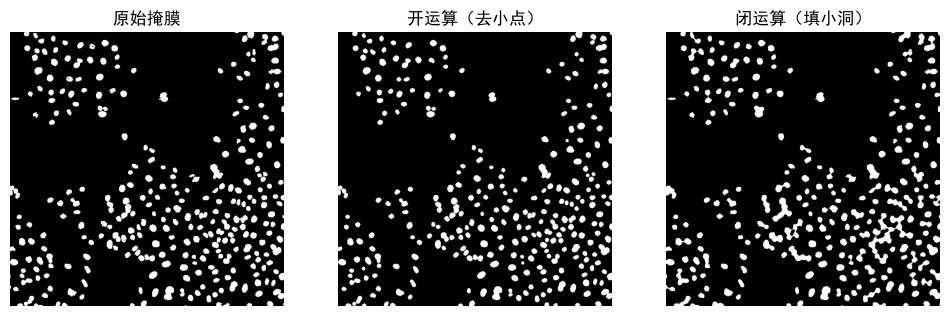

In [12]:
# 形态学操作
cells = data.human_mitosis()
thresh = filters.threshold_otsu(cells)
mask = cells > thresh
print("threshold:", thresh, "目标像素占比:", mask.mean())
kernel = disk(3)
opened = opening(mask, kernel)
closed = closing(mask, kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(mask, cmap="gray");   axes[0].set_title("原始掩膜")
axes[1].imshow(opened, cmap="gray"); axes[1].set_title("开运算（去小点）")
axes[2].imshow(closed, cmap="gray"); axes[2].set_title("闭运算（填小洞）")
for ax in axes: ax.axis("off")
plt.savefig("outputs/06_morphology.png", dpi=120, bbox_inches="tight")
plt.show()

## 十、用 OpenCV 做一遍对照

### 说明

前面九节都是用 skimage 完成的，这一节用 OpenCV 把关键操作再做一遍。

### 三处差异（下面都亲手验证过）

| 差异点 | skimage | OpenCV |
| --- | --- | --- |
| 读图的通道顺序 | RGB | **BGR** |
| 尺寸参数的顺序 | `(高, 宽)`，和数组 `.shape` 一致 | `(宽, 高)`，和数组 `.shape` **相反** |
| 阈值函数的返回值 | 只返回掩膜（1 个值） | 返回阈值和结果（**2 个值**） |


### 我观察到

- 同一个像素，skimage 读出 `[44 39 40]`、cv2 读出 `[40 39 44]`，红蓝正好对调；用 `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` 转过之后，和 skimage 的结果**完全相同**（`np.array_equal` 返回 True）。
- `cv2.resize` 参数写反**不会报错**，只是图被拉伸变形：想要"宽 256、高 128"却写成 `(128, 256)`，得到的数组 shape 是 `(256, 128)`。这类"不报错的错误"最难发现，只能靠核对形状。
- `cv2.threshold` 返回两个值，所以要写 `_, binary = ...`，否则会把第一个返回值（阈值本身）当成图像。
- OpenCV 的结构元是 numpy 数组（`np.ones((5, 5), np.uint8)`），skimage 是 `disk(3)` 这样的现成形状——两者做的是同一件事。

In [13]:
# 差异一：读图的通道顺序
img_skimage = io.imread("outputs/kidney.png")            # RGB
img_cv2 = cv2.imread("outputs/kidney.png")               # BGR（默认按彩色读）
img_cv2_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)   # 转成 RGB 才能和 skimage 对齐

print("skimage 读:", img_skimage.shape, img_skimage.dtype)
print("cv2     读:", img_cv2.shape, img_cv2.dtype)
print("同一个像素 skimage:", img_skimage[0, 0], " cv2:", img_cv2[0, 0])
print("把 cv2 的结果转成 RGB 后，和 skimage 完全一致吗:", np.array_equal(img_cv2_rgb, img_skimage))

skimage 读: (512, 512, 3) uint8
cv2     读: (512, 512, 3) uint8
同一个像素 skimage: [44 39 40]  cv2: [40 39 44]
把 cv2 的结果转成 RGB 后，和 skimage 完全一致吗: True


In [14]:
# 差异二：cv2.resize 的参数顺序是 (宽, 高)，和数组的 (行, 列) 相反
gray_cv2 = cv2.imread("outputs/kidney.png", cv2.IMREAD_GRAYSCALE)
print("灰度模式读入:", gray_cv2.shape, gray_cv2.dtype)

resized_a = cv2.resize(gray_cv2, (256, 128))   # 想说"宽 256、高 128"
resized_b = cv2.resize(gray_cv2, (128, 256))   # 参数写反
print("cv2.resize(img, (256, 128)) 得到的数组 shape:", resized_a.shape)
print("cv2.resize(img, (128, 256)) 得到的数组 shape:", resized_b.shape)

灰度模式读入: (512, 512) uint8
cv2.resize(img, (256, 128)) 得到的数组 shape: (128, 256)
cv2.resize(img, (128, 256)) 得到的数组 shape: (256, 128)


返回的阈值: 100.0  结果 shape: (512, 512)  取值: [  0 255]
二值化后目标像素占比: 0.09
开运算后目标像素占比: 0.0403


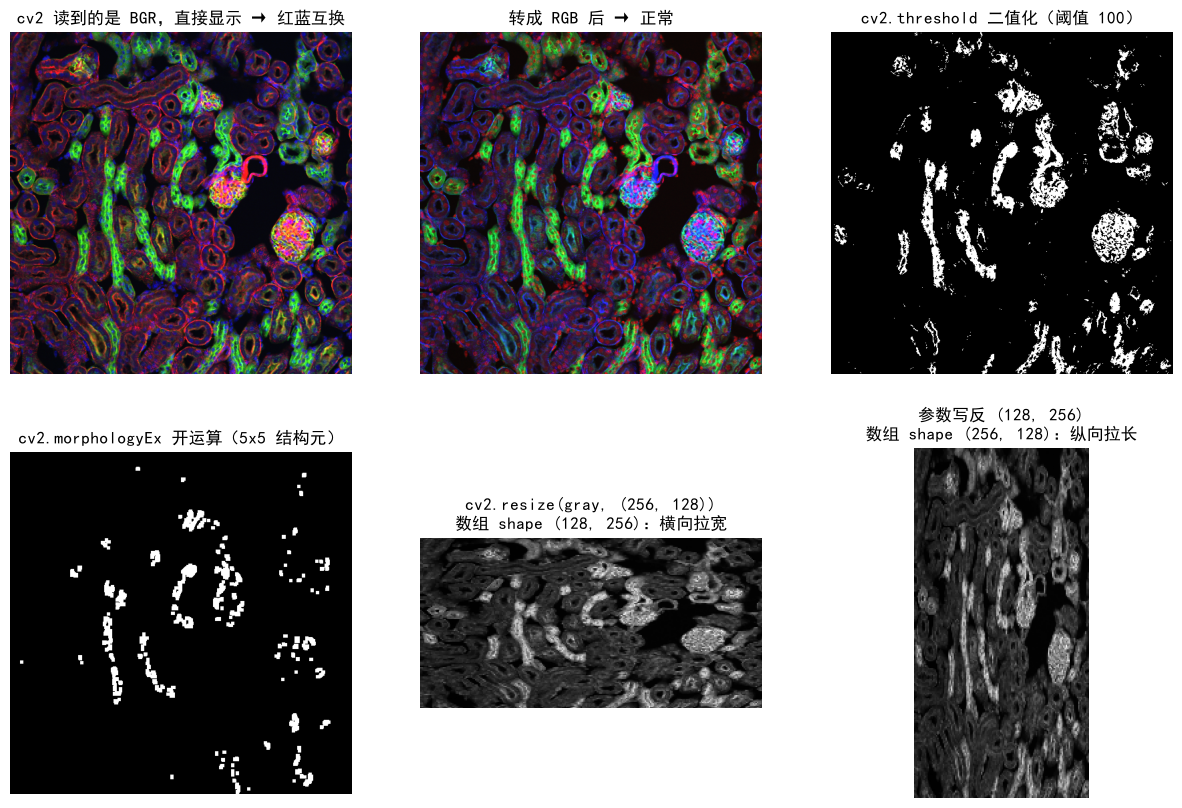

In [15]:
# 差异三：cv2.threshold 返回两个值（阈值 + 结果图）
# 同样的开运算，用 skimage 写是 morphology.binary_opening(mask, disk(3))
threshold_value, binary_cv2 = cv2.threshold(gray_cv2, 100, 255, cv2.THRESH_BINARY)
print("返回的阈值:", threshold_value, " 结果 shape:", binary_cv2.shape, " 取值:", np.unique(binary_cv2))
print("二值化后目标像素占比:", round(float((binary_cv2 > 0).mean()), 4))

kernel = np.ones((5, 5), np.uint8)
opened_cv2 = cv2.morphologyEx(binary_cv2, cv2.MORPH_OPEN, kernel)
print("开运算后目标像素占比:", round(float((opened_cv2 > 0).mean()), 4))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(img_cv2);                 axes[0, 0].set_title("cv2 读到的是 BGR，直接显示 → 红蓝互换")
axes[0, 1].imshow(img_cv2_rgb);             axes[0, 1].set_title("转成 RGB 后 → 正常")
axes[0, 2].imshow(binary_cv2, cmap="gray"); axes[0, 2].set_title("cv2.threshold 二值化（阈值 100）")
axes[1, 0].imshow(opened_cv2, cmap="gray"); axes[1, 0].set_title("cv2.morphologyEx 开运算（5x5 结构元）")
axes[1, 1].imshow(resized_a, cmap="gray");  axes[1, 1].set_title("cv2.resize(gray, (256, 128))\n数组 shape (128, 256)：横向拉宽")
axes[1, 2].imshow(resized_b, cmap="gray");  axes[1, 2].set_title("参数写反 (128, 256)\n数组 shape (256, 128)：纵向拉长")
for ax in axes.ravel():
    ax.axis("off")
plt.savefig("outputs/07_opencv.png", dpi=120, bbox_inches="tight")
plt.show()

---

## 附一：为什么第一张图看起来"一片白"

（这一节回答 cell 2 里留的问题。）

`plt.imshow` 处理图像亮度的规则是**按通道数分岔**的：

| 图像类型 | matplotlib 的处理 | 怎么控制显示范围 |
| --- | --- | --- |
| 单通道 `(H, W)` | 按数据范围自动缩放 | `cmap` / `vmin` / `vmax` |
| 多通道 `(H, W, 3)` | **不自动缩放**，只认 0~1（float）或 0~255（整数） | `vmin` / `vmax` |

我们的数据是 `(512, 512, 3)` 的 uint16，最大值 4095，远超 255。matplotlib 把超过 255 的值按 255 处理（等于截断），于是一片纯白；同时因为是多通道，`cmap='gray'` 也会被忽略。

### 三种解决办法

1. 只取一个通道显示：`plt.imshow(slice_2d[:, :, 0], cmap='gray')`
2. 手动指定显示范围：`plt.imshow(slice_2d, vmin=0, vmax=4095)`
3. 先换算刻度：`(x / x.max() * 255).astype(np.uint8)`（本 notebook 用的这种）

### 方法论

**图像显示不正常时，先怀疑"数据范围 / 数据类型 / 通道数"，最后才怀疑代码写错了。** 这三样东西在医学图像里几乎每次都不一样，先看它们能省下大量时间。

---

## 附二：本阶段验收记录

- **完成时间**：2026-09-13 ~ 2026-09-14
- **覆盖的操作**：图像 IO、灰度转换、坐标变换（缩放 / 旋转 / 翻转）、直方图与直方图均衡、形态学操作（开 / 闭运算）
- **使用工具**：scikit-image 0.26.0、OpenCV 5.0.0、matplotlib 3.11.1
- **产出**：
  - `outputs/` 下 7 张图（01~06 是各操作的对比图，07 是 OpenCV 对照）
  - 可复用的预处理脚本 `preprocess.py`（含命令行入口）
- **脚本验收**：输入 `(512, 512, 3)` uint8 → 输出 `(224, 224)` float32，取值 0~1；
  加 `--equalize` 后取值 0.0108~1.0000（均衡把范围铺满，符合预期）
- **踩过的坑**：
  1. `cv2.imread` 默认按 BGR 顺序读，且 `cv2.resize` 的参数是 (宽, 高)，与 numpy 相反（实验见第十节）
  2. 保存前必须显式转回 uint8，否则 PNG 会有精度损失警告
  3. 从 notebook 复制到 .py 时带上了 `IPython` 相关的 import——服务器上没装 IPython，会直接报错
  4. **处理结果不能覆盖输入文件**：原始数据只读、结果另存，这是数据安全的基本纪律
  5. 彩色图直接做直方图均衡会产生色偏（见第八节）
  6. 形态学 kernel 取太大（disk(6)）会误删真目标（见第九节）

---

## 附三：必须记住的几条（复盘用）

1. **拿到任何图像，先看 shape / dtype / min / max。** 三个值一打印，绝大多数"图显示不出来 / 全黑 / 全白"的问题当场就能定位。
2. **dtype 决定取值范围**：uint8 是 0~255，float 是 0~1。动手前先看 dtype，两种混用必然出错。
3. **归一化 ≠ 拉伸**。`img_as_float32` 是按满量程忠实换算，min-max 拉伸是把当前范围铺满。前者保证不同图像之间可比，后者只是为了看得清。
4. **多通道图不能直接做直方图或直方图均衡**。先转灰度，或者只在 HSV 的 V 通道上做。
5. **matplotlib 显示**：灰度图要 `cmap='gray'`；多通道图不做自动缩放，超出范围会被截断成白色。
6. **医学图像的三点特殊性**：3D 体数据（多个断层）、高位深（12/16 位）、通道有物理含义。
7. **数据增强要服从领域物理含义**。衣服可以随便翻转，胸片不行——左右方位有诊断意义。
8. **形态学的 kernel 大小是取舍**：越大清理越狠，也越容易误删真目标（11.36% → 0.66% 就是证据）。